In [ ]:
# NSSC 2026
## Unsupervised Anomaly Detection in Mars HiRISE Orbital Imagery

### Team:
### Members:
### Institute:

In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!pip -q install umap-learn

In [ ]:
import os
import glob
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras import backend as K

from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.manifold import TSNE

import umap.umap_ as umap

warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = 227
LATENT_DIM = 256
BATCH_SIZE = 64
EPOCHS = 50

print("Image size:", IMG_SIZE)
print("Latent dimension:", LATENT_DIM)
print("Batch size:", BATCH_SIZE)

Image size: 227
Latent dimension: 256
Batch size: 64


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print("MyDrive folders:")
print(os.listdir("/content/drive/MyDrive"))

MyDrive folders:
['A12_MY (1).klck', 'A12_MY.klck', 'Android 12 Lockscreen By Mr. Nikhil Tech.zip', 'Untitled form (File responses)', 'img20240310_10073095.pdf', 'Shambhunath Rajjak Offer Letter.pdf', 'Shubham sheet.gsheet', 'Untitled spreadsheet (3).gsheet', 'Untitled spreadsheet (2).gsheet', 'Untitled spreadsheet (1).gsheet', 'Untitled spreadsheet.xlsx', 'Screenshot_20250724-171257.png', 'Documents-Required-2025-26 (1)_copy.pdf', 'Shubham uiet.pdf_20250814_214403_0000_copy.pdf', 'Share DOC-20250727-WA0135..pdf', 'IMG_20250905_212614_919 (2).jpg', 'IMG_20250905_212614_919 (1).jpg', 'IMG_20250905_212614_919.jpg', 'seat no and mobile no HSC Students.pdf', 'EchoDocs Report.pdf', 'Untitled document (7).gdoc', 'Untitled document (6).gdoc', 'IMG_20251014_150220_016.jpg', 'Screenshot_20251014-211811 (1).png', 'Screenshot_20251014-211811.png', 'Screenshot_20251014-211856 (1).png', 'Screenshot_20251014-211856.png', 'Untitled document (5).gdoc', 'IMG_20251022_164450_074.jpg', 'Untitled spreadsh

In [ ]:
import os

NSSC_PATH = "/content/drive/MyDrive/NSSC_2026"

print("NSSC_2026 exists:", os.path.exists(NSSC_PATH))
print("\nContents of NSSC_2026:")
print(os.listdir(NSSC_PATH))

NSSC_2026 exists: True

Contents of NSSC_2026:
['images', 'source_image_metadata.csv']


In [ ]:
import os

NSSC_PATH = "/content/drive/MyDrive/NSSC_2026"
IMAGE_DIR = os.path.join(NSSC_PATH, "images")

print("Images folder exists:", os.path.exists(IMAGE_DIR))

if os.path.exists(IMAGE_DIR):
    files = os.listdir(IMAGE_DIR)
    print("Number of files:", len(files))
    print("First 10 files:")
    print(files[:10])

Images folder exists: True
Number of files: 10422
First 10 files:
['sample_09423.jpg', 'sample_09424.jpg', 'sample_09425.jpg', 'sample_09426.jpg', 'sample_09427.jpg', 'sample_09428.jpg', 'sample_09429.jpg', 'sample_09430.jpg', 'sample_09431.jpg', 'sample_09432.jpg']


In [ ]:
import os
import glob

NSSC_PATH = "/content/drive/MyDrive/NSSC_2026"

# Find all JPG/JPEG/PNG images inside NSSC_2026 and its subfolders
image_files = sorted(
    glob.glob(os.path.join(NSSC_PATH, "**", "*.jpg"), recursive=True) +
    glob.glob(os.path.join(NSSC_PATH, "**", "*.jpeg"), recursive=True) +
    glob.glob(os.path.join(NSSC_PATH, "**", "*.png"), recursive=True)
)

print("Number of images:", len(image_files))

print("\nFirst 10 images:")
for f in image_files[:10]:
    print(f)

Number of images: 10422

First 10 images:
/content/drive/MyDrive/NSSC_2026/images/sample_00001.jpg
/content/drive/MyDrive/NSSC_2026/images/sample_00002.jpg
/content/drive/MyDrive/NSSC_2026/images/sample_00003.jpg
/content/drive/MyDrive/NSSC_2026/images/sample_00004.jpg
/content/drive/MyDrive/NSSC_2026/images/sample_00005.jpg
/content/drive/MyDrive/NSSC_2026/images/sample_00006.jpg
/content/drive/MyDrive/NSSC_2026/images/sample_00007.jpg
/content/drive/MyDrive/NSSC_2026/images/sample_00008.jpg
/content/drive/MyDrive/NSSC_2026/images/sample_00009.jpg
/content/drive/MyDrive/NSSC_2026/images/sample_00010.jpg


In [ ]:
from PIL import Image
import numpy as np
import os

IMG_SIZE = 227

images = []
image_ids = []

errors = []

for file_path in image_files:
    file_name = os.path.basename(file_path)

    try:
        img = Image.open(file_path).convert("L")
        img = img.resize((IMG_SIZE, IMG_SIZE))

        img_array = np.array(img, dtype=np.float32) / 255.0

        images.append(img_array)
        image_ids.append(file_name)

    except Exception as e:
        errors.append((file_name, str(e)))

images = np.array(images)

print("Total images loaded:", len(images))
print("Images shape:", images.shape)
print("Minimum pixel value:", images.min())
print("Maximum pixel value:", images.max())
print("Loading errors:", len(errors))

Total images loaded: 10422
Images shape: (10422, 227, 227)
Minimum pixel value: 0.0
Maximum pixel value: 1.0
Loading errors: 0


Image file: /content/drive/MyDrive/NSSC_2026/images/sample_00001.jpg
Original image size: (227, 227)


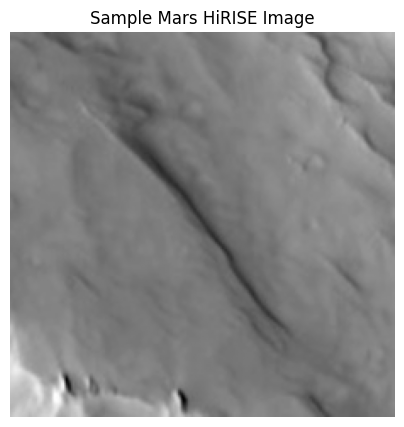

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

test_image = Image.open(image_files[0]).convert("L")

print("Image file:", image_files[0])
print("Original image size:", test_image.size)

plt.figure(figsize=(5, 5))
plt.imshow(test_image, cmap="gray")
plt.axis("off")
plt.title("Sample Mars HiRISE Image")
plt.show()

In [ ]:
import numpy as np
import tensorflow as tf

IMG_SIZE = 227
BATCH_SIZE = 64

# Make sure image_files exists
print("Images detected:", len(image_files))

# Convert to NumPy array
image_paths = np.array(image_files)

# Shuffle
np.random.seed(42)
np.random.shuffle(image_paths)

# 90% training / 10% validation
split_index = int(0.9 * len(image_paths))

train_paths = image_paths[:split_index]
val_paths = image_paths[split_index:]

print("Total images:", len(image_paths))
print("Training images:", len(train_paths))
print("Validation images:", len(val_paths))

Images detected: 10422
Total images: 10422
Training images: 9379
Validation images: 1043


In [ ]:
def load_and_preprocess_image(file_path):
    image = tf.io.read_file(file_path)

    image = tf.image.decode_jpeg(
        image,
        channels=1
    )

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE]
    )

    image = tf.cast(image, tf.float32) / 255.0

    return image

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices(train_paths)

train_dataset = train_dataset.map(
    load_and_preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset = train_dataset.batch(BATCH_SIZE)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)


val_dataset = tf.data.Dataset.from_tensor_slices(val_paths)

val_dataset = val_dataset.map(
    load_and_preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_dataset = val_dataset.batch(BATCH_SIZE)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)

print("Datasets created successfully!")

Datasets created successfully!


In [ ]:
for batch in train_dataset.take(1):
    print("Batch shape:", batch.shape)
    print("Minimum pixel value:", tf.reduce_min(batch).numpy())
    print("Maximum pixel value:", tf.reduce_max(batch).numpy())

Batch shape: (64, 227, 227, 1)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


## Phase 1 — Deep Latent Compression

### V1 Baseline Convolutional Autoencoder

The V1 model is a custom convolutional autoencoder trained from scratch.
It learns a compact latent representation of Mars HiRISE imagery
without using pretrained feature extractors or ground-truth labels.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

LATENT_DIM = 256

# =========================
# V1 ENCODER
# =========================

encoder_input = layers.Input(
    shape=(227, 227, 1),
    name="encoder_input"
)

x = layers.Conv2D(
    32, 3, strides=2, padding="same", activation="relu"
)(encoder_input)

x = layers.Conv2D(
    64, 3, strides=2, padding="same", activation="relu"
)(x)

x = layers.Conv2D(
    128, 3, strides=2, padding="same", activation="relu"
)(x)

x = layers.Conv2D(
    256, 3, strides=2, padding="same", activation="relu"
)(x)

x = layers.Flatten()(x)

latent = layers.Dense(
    LATENT_DIM,
    name="latent_vector"
)(x)

encoder = Model(
    encoder_input,
    latent,
    name="V1_Encoder"
)


# =========================
# V1 DECODER
# =========================

decoder_input = layers.Input(
    shape=(LATENT_DIM,),
    name="decoder_input"
)

x = layers.Dense(
    15 * 15 * 256,
    activation="relu"
)(decoder_input)

x = layers.Reshape(
    (15, 15, 256)
)(x)

x = layers.Conv2DTranspose(
    128, 3, strides=2, padding="same", activation="relu"
)(x)

x = layers.Conv2DTranspose(
    64, 3, strides=2, padding="same", activation="relu"
)(x)

x = layers.Conv2DTranspose(
    32, 3, strides=2, padding="same", activation="relu"
)(x)

x = layers.Conv2DTranspose(
    16, 3, strides=2, padding="same", activation="relu"
)(x)

decoder_output = layers.Conv2D(
    1,
    3,
    padding="same",
    activation="sigmoid"
)(x)

# 240x240 -> 227x227
decoder_output = layers.Cropping2D(
    cropping=((6, 7), (6, 7))
)(decoder_output)

decoder = Model(
    decoder_input,
    decoder_output,
    name="V1_Decoder"
)


# =========================
# COMPLETE AUTOENCODER
# =========================

autoencoder_input = layers.Input(
    shape=(227, 227, 1),
    name="autoencoder_input"
)

latent_vector = encoder(autoencoder_input)

reconstruction = decoder(latent_vector)

autoencoder = Model(
    autoencoder_input,
    reconstruction,
    name="V1_Autoencoder"
)

autoencoder.summary()

print("Final reconstruction shape:", reconstruction.shape)

Model: "V1_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ autoencoder_input (InputLayer)  │ (None, 227, 227, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ V1_Encoder (Functional)         │ (None, 256)            │    15,133,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ V1_Decoder (Functional)         │ (None, 227, 227, 1)    │    15,195,265 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,328,961 (115.70 MB)

 Trainable params: 30,328,961 (115.70 MB)

 Non-trainable params: 0 (0.00 B)

Final reconstruction shape: (None, 227, 227, 1)


In [ ]:
# STEP 10 — Compile V1 Autoencoder

autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse"
)

print("V1 Autoencoder compiled successfully!")

V1 Autoencoder compiled successfully!


In [ ]:
# STEP 11A — Prepare datasets for Autoencoder training

train_dataset_ae = train_dataset.map(
    lambda image: (image, image),
    num_parallel_calls=tf.data.AUTOTUNE
)

val_dataset_ae = val_dataset.map(
    lambda image: (image, image),
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset_ae = train_dataset_ae.prefetch(tf.data.AUTOTUNE)
val_dataset_ae = val_dataset_ae.prefetch(tf.data.AUTOTUNE)

print("Autoencoder datasets prepared successfully!")

Autoencoder datasets prepared successfully!


In [ ]:
# STEP 11C — CHECK DATASET FORMAT

print("Checking training dataset...")

print("Train dataset element spec:")
print(train_dataset.element_spec)

print("\nValidation dataset element spec:")
print(val_dataset.element_spec)

print("\nAutoencoder input shape:")
print(autoencoder.input_shape)

print("\nAutoencoder output shape:")
print(autoencoder.output_shape)

# Check one batch
for batch in train_dataset.take(1):
    print("\nActual batch shape:", batch.shape)
    print("Data type:", batch.dtype)
    print("Minimum:", tf.reduce_min(batch).numpy())
    print("Maximum:", tf.reduce_max(batch).numpy())

print("\nDataset check completed.")

Checking training dataset...
Train dataset element spec:
TensorSpec(shape=(None, 227, 227, 1), dtype=tf.float32, name=None)

Validation dataset element spec:
TensorSpec(shape=(None, 227, 227, 1), dtype=tf.float32, name=None)

Autoencoder input shape:
(None, 227, 227, 1)

Autoencoder output shape:
(None, 227, 227, 1)

Actual batch shape: (64, 227, 227, 1)
Data type: <dtype: 'float32'>
Minimum: 0.0
Maximum: 1.0

Dataset check completed.


In [ ]:
# STEP 11D — FINAL DATASET CHECK

print("TRAIN DATASET:")
print("Element spec:", train_dataset.element_spec)

print("\nTRAIN BATCH:")
train_batch = next(iter(train_dataset))
print("Shape:", train_batch.shape)
print("Min:", tf.reduce_min(train_batch).numpy())
print("Max:", tf.reduce_max(train_batch).numpy())

print("\nVALIDATION DATASET:")
print("Element spec:", val_dataset.element_spec)

print("\nDATASET CHECK FINISHED")

TRAIN DATASET:
Element spec: TensorSpec(shape=(None, 227, 227, 1), dtype=tf.float32, name=None)

TRAIN BATCH:
Shape: (64, 227, 227, 1)
Min: 0.0
Max: 1.0

VALIDATION DATASET:
Element spec: TensorSpec(shape=(None, 227, 227, 1), dtype=tf.float32, name=None)

DATASET CHECK FINISHED


In [ ]:
# STEP 11E — FIX V1 AUTOENCODER TRAINING

import tensorflow as tf

print("Rebuilding training datasets...")

# Create datasets with explicit input-target pairs
train_dataset_ae = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_paths)
)

val_dataset_ae = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_paths)
)

# Load both input and target images
def load_pair(path1, path2):
    image1 = load_and_preprocess_image(path1)
    image2 = load_and_preprocess_image(path2)
    return image1, image2

train_dataset_ae = train_dataset_ae.map(
    load_pair,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_dataset_ae = val_dataset_ae.map(
    load_pair,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Batch and prefetch
train_dataset_ae = train_dataset_ae.batch(BATCH_SIZE).prefetch(
    tf.data.AUTOTUNE
)

val_dataset_ae = val_dataset_ae.batch(BATCH_SIZE).prefetch(
    tf.data.AUTOTUNE
)

print("Datasets rebuilt successfully!")

# Check dataset structure
for x_batch, y_batch in train_dataset_ae.take(1):
    print("Input shape :", x_batch.shape)
    print("Target shape:", y_batch.shape)

# Start V1 training
print("\nStarting V1 Autoencoder training...")

history_v1 = autoencoder.fit(
    train_dataset_ae,
    validation_data=val_dataset_ae,
    epochs=50,
    verbose=1
)

print("\nV1 training completed successfully!")

Rebuilding training datasets...
Datasets rebuilt successfully!
Input shape : (64, 227, 227, 1)
Target shape: (64, 227, 227, 1)

Starting V1 Autoencoder training...
Epoch 1/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 64s 314ms/step - loss: 0.0190 - val_loss: 0.0054
Epoch 2/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 26s 180ms/step - loss: 0.0048 - val_loss: 0.0047
Epoch 3/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 27s 182ms/step - loss: 0.0042 - val_loss: 0.0044
Epoch 4/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 28s 187ms/step - loss: 0.0038 - val_loss: 0.0039
Epoch 5/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 27s 182ms/step - loss: 0.0036 - val_loss: 0.0038
Epoch 6/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 27s 186ms/step - loss: 0.0033 - val_loss: 0.0034
Epoch 7/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 27s 186ms/step - loss: 0.0032 - val_loss: 0.0034
Epoch 8/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 29s 198ms/step - loss: 0.0031 - val_loss: 0.0032
Epoch 9/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 27s 184ms/step - loss: 0.0030 - val_loss: 0.0031
Epoch 10/50
147/147 ━━━━━━━━━━━━━━━

In [ ]:
# STEP 11F — FIX KERAS TRAINING ERROR

print("Recompiling V1 Autoencoder...")

autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="mse",
    run_eagerly=True
)

print("Autoencoder recompiled successfully!")

print("\nStarting V1 training...")

history_v1 = autoencoder.fit(
    train_dataset_ae,
    validation_data=val_dataset_ae,
    epochs=50,
    steps_per_epoch=len(train_paths) // BATCH_SIZE,
    validation_steps=len(val_paths) // BATCH_SIZE,
    verbose=1
)

print("\nV1 training completed successfully!")

In [ ]:
# Check that Colab is actually seeing the T4 GPU
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

if tf.config.list_physical_devices("GPU"):
    print("✅ T4 GPU is available")
else:
    print("❌ GPU not detected")

In [ ]:
# STEP 12A — Recreate V1 Autoencoder

import tensorflow as tf
from tensorflow.keras import layers, Model

LATENT_DIM = 256

# -------- ENCODER --------
encoder_input = layers.Input(
    shape=(227, 227, 1),
    name="encoder_input"
)

x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(encoder_input)
x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
x = layers.Conv2D(128, 3, strides=2, padding="same", activation="relu")(x)
x = layers.Conv2D(256, 3, strides=2, padding="same", activation="relu")(x)

x = layers.Flatten()(x)
latent = layers.Dense(LATENT_DIM, name="latent_vector")(x)

encoder = Model(
    encoder_input,
    latent,
    name="V1_Encoder"
)

# -------- DECODER --------
decoder_input = layers.Input(
    shape=(LATENT_DIM,),
    name="decoder_input"
)

x = layers.Dense(
    15 * 15 * 256,
    activation="relu"
)(decoder_input)

x = layers.Reshape((15, 15, 256))(x)

x = layers.Conv2DTranspose(
    128, 3, strides=2,
    padding="same",
    activation="relu"
)(x)

x = layers.Conv2DTranspose(
    64, 3, strides=2,
    padding="same",
    activation="relu"
)(x)

x = layers.Conv2DTranspose(
    32, 3, strides=2,
    padding="same",
    activation="relu"
)(x)

x = layers.Conv2DTranspose(
    16, 3, strides=2,
    padding="same",
    activation="relu"
)(x)

decoder_output = layers.Conv2D(
    1, 3,
    padding="same",
    activation="sigmoid"
)(x)

# 240x240 → 227x227
decoder_output = layers.Cropping2D(
    cropping=((6, 7), (6, 7))
)(decoder_output)

decoder = Model(
    decoder_input,
    decoder_output,
    name="V1_Decoder"
)

# -------- AUTOENCODER --------
autoencoder_input = layers.Input(
    shape=(227, 227, 1),
    name="autoencoder_input"
)

latent_vector = encoder(autoencoder_input)
reconstruction = decoder(latent_vector)

autoencoder = Model(
    autoencoder_input,
    reconstruction,
    name="V1_Autoencoder"
)

print("✅ V1 Autoencoder recreated")
print("Latent dimension:", LATENT_DIM)
print("Input shape:", autoencoder.input_shape)
print("Output shape:", autoencoder.output_shape)

In [ ]:
# STEP 12B — Compile V1 for T4 GPU

autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse"
)

print("✅ V1 compiled successfully")

In [ ]:
# STEP 13B — Recover image paths + train/validation split + dataset

import os
import glob
import numpy as np
import tensorflow as tf

NSSC_PATH = "/content/drive/MyDrive/NSSC_2026"

# 1. Find all images again
image_files = sorted(
    glob.glob(os.path.join(NSSC_PATH, "**", "*.jpg"), recursive=True) +
    glob.glob(os.path.join(NSSC_PATH, "**", "*.jpeg"), recursive=True) +
    glob.glob(os.path.join(NSSC_PATH, "**", "*.png"), recursive=True)
)

print("Total images:", len(image_files))

# 2. Recreate train/validation split
image_paths = np.array(image_files)

np.random.seed(42)
np.random.shuffle(image_paths)

split_index = int(0.9 * len(image_paths))

train_paths = image_paths[:split_index]
val_paths = image_paths[split_index:]

print("Training images:", len(train_paths))
print("Validation images:", len(val_paths))

# 3. Image preprocessing
IMG_SIZE = 227
BATCH_SIZE = 64

def load_and_preprocess_image(file_path):
    image = tf.io.read_file(file_path)
    image = tf.image.decode_jpeg(image, channels=1)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image

# 4. Create autoencoder dataset
def load_pair(path1, path2):
    image1 = load_and_preprocess_image(path1)
    image2 = load_and_preprocess_image(path2)
    return image1, image2

train_dataset_ae = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_paths)
)

train_dataset_ae = train_dataset_ae.map(
    load_pair,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset_ae = train_dataset_ae.batch(BATCH_SIZE)
train_dataset_ae = train_dataset_ae.prefetch(tf.data.AUTOTUNE)

print("✅ Dataset recreated successfully")

# 5. Verify batch
x_batch, y_batch = next(iter(train_dataset_ae))

print("Input batch :", x_batch.shape)
print("Target batch:", y_batch.shape)

In [ ]:
# STEP 14 — T4 GPU Speed Test

import time

start_time = time.time()

history_test = autoencoder.fit(
    train_dataset_ae,
    epochs=1,
    steps_per_epoch=5,
    verbose=1
)

elapsed = time.time() - start_time

print("\n✅ Speed test completed")
print(f"Total time: {elapsed:.1f} seconds")
print(f"Average time per batch: {elapsed/5:.1f} seconds")

In [ ]:
# STEP 15 — V1 Autoencoder Training

import time

start_time = time.time()

history_v1 = autoencoder.fit(
    train_dataset_ae,
    validation_data=val_dataset_ae if "val_dataset_ae" in globals() else None,
    epochs=10,
    steps_per_epoch=len(train_paths) // BATCH_SIZE,
    validation_steps=len(val_paths) // BATCH_SIZE if "val_dataset_ae" in globals() else None,
    verbose=1
)

elapsed = time.time() - start_time

print("\n✅ V1 training completed")
print(f"Total training time: {elapsed/60:.1f} minutes")

In [ ]:
# STEP 16 — V1 Reconstruction Visualization

import matplotlib.pyplot as plt
import numpy as np

# Take one batch from validation data
val_batch = next(iter(val_dataset))

# Reconstruct images
reconstructed = autoencoder.predict(val_batch, verbose=0)

# Show original and reconstructed images
n = 5

plt.figure(figsize=(12, 5))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(val_batch[i].numpy().squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("Original")

    # Reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("V1 Reconstruction")

plt.suptitle("V1 Autoencoder: Original vs Reconstruction")
plt.tight_layout()
plt.show()

In [ ]:
# Step 17 — Plot V1 training history

plt.figure(figsize=(8, 5))

plt.plot(history_v1.history["loss"], label="Training Loss")

if "val_loss" in history_v1.history:
    plt.plot(history_v1.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("V1 Autoencoder Training History")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print("Final training loss:", history_v1.history["loss"][-1])

if "val_loss" in history_v1.history:
    print("Final validation loss:", history_v1.history["val_loss"][-1])

## 1.2 Reconstruction Quality Evaluation

We evaluate whether the trained autoencoder can reconstruct unseen
validation images from their 256-dimensional latent representations.

Both visual reconstruction quality and reconstruction MSE are examined.

In [ ]:
# Step 18 — Reconstruct validation images

val_batch = next(iter(val_dataset))

reconstructed = autoencoder.predict(
    val_batch,
    verbose=0
)

print("Original shape:", val_batch.shape)
print("Reconstructed shape:", reconstructed.shape)

In [ ]:
# Step 18.1 — Visual comparison

n_images = 8

plt.figure(figsize=(16, 4))

for i in range(n_images):
    # Original
    plt.subplot(2, n_images, i + 1)
    plt.imshow(val_batch[i].numpy().squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.ylabel("Original")

    # Reconstruction
    plt.subplot(2, n_images, n_images + i + 1)
    plt.imshow(reconstructed[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.ylabel("Reconstructed")

plt.suptitle("V1 Autoencoder — Original vs Reconstruction")
plt.tight_layout()
plt.show()

In [ ]:
# Step 18.2 — Per-image reconstruction MSE

recon_mse = np.mean(
    (val_batch.numpy() - reconstructed) ** 2,
    axis=(1, 2, 3)
)

print("Mean reconstruction MSE:", recon_mse.mean())
print("Minimum reconstruction MSE:", recon_mse.min())
print("Maximum reconstruction MSE:", recon_mse.max())

## 1.3 Latent Representation Extraction

The trained encoder converts each 227×227 grayscale image into a fixed
256-dimensional latent vector.

These latent representations provide a compact feature space for
subsequent unsupervised anomaly detection.

In [ ]:
# Step 19 — Extract latent vectors from validation images

latent_val = encoder.predict(
    val_dataset,
    verbose=1
)

print("Latent representation shape:", latent_val.shape)

In [ ]:
print("Latent dimension:", latent_val.shape[1])
print("Number of validation samples:", latent_val.shape[0])
print("Latent minimum:", latent_val.min())
print("Latent maximum:", latent_val.max())

## 1.4 Latent Space Visualization using t-SNE

To qualitatively inspect the learned latent representations, we project
the 256-dimensional latent vectors into a 2-dimensional space using t-SNE.

Since the dataset is unlabeled, the visualization is used only as a
diagnostic of latent-space structure and is not treated as ground-truth
anomaly detection.

In [ ]:
# Step 20 — t-SNE visualization

from sklearn.manifold import TSNE

# Use a subset to keep t-SNE computationally manageable
n_tsne = min(1000, len(latent_val))

rng = np.random.default_rng(42)
tsne_indices = rng.choice(
    len(latent_val),
    size=n_tsne,
    replace=False
)

latent_subset = latent_val[tsne_indices]

print("Vectors used for t-SNE:", latent_subset.shape)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=42
)

latent_2d = tsne.fit_transform(latent_subset)

print("t-SNE output shape:", latent_2d.shape)

In [ ]:
# Step 20.1 — Plot t-SNE projection

plt.figure(figsize=(8, 6))

plt.scatter(
    latent_2d[:, 0],
    latent_2d[:, 1],
    s=10,
    alpha=0.7
)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("t-SNE Visualization of 256-D Latent Representations")
plt.grid(True)
plt.show()

## 1.5 Phase 1 Evaluation

The convolutional autoencoder successfully compresses each 227×227
grayscale image into a fixed 256-dimensional latent representation.

Reconstruction MSE is used to evaluate the basic reconstruction quality,
while the t-SNE projection provides a qualitative view of the learned
latent space.

The latent vectors will be used as the feature representation for the
subsequent unsupervised anomaly detection stage.

In [ ]:
# Step 21 — Phase 1 summary

print("========== PHASE 1 SUMMARY ==========")
print("Input image size      :", (IMG_SIZE, IMG_SIZE, 1))
print("Training samples      :", len(train_paths))
print("Validation samples    :", len(val_paths))
print("Latent dimension      :", latent_val.shape[1])
print("Latent vectors        :", latent_val.shape)
print("Mean reconstruction MSE:", recon_mse.mean())
print("=====================================")

In [ ]:
# Save V1 encoder

os.makedirs("/content/drive/MyDrive/NSSC_2026/models", exist_ok=True)

encoder.save(
    "/content/drive/MyDrive/NSSC_2026/models/V1_encoder.keras"
)

print("V1 encoder saved successfully.")

## 1.6 V2 — Structural Reconstruction Improvement

### Symptom
V1 uses only pixel-wise MSE, which can produce overly smooth
reconstructions and may lose fine terrain structures.

### Diagnosis
Pixel-wise MSE measures average intensity differences but does not
explicitly preserve structural similarity.

### Fix
V2 combines MSE with SSIM-based loss to encourage preservation of
local terrain structures while maintaining pixel-level reconstruction.

No pretrained models or feature extractors are used.

In [ ]:
# Step 22 — V2 combined MSE + SSIM loss

def combined_mse_ssim_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))

    ssim = tf.image.ssim(
        y_true,
        y_pred,
        max_val=1.0
    )

    ssim_loss = 1.0 - tf.reduce_mean(ssim)

    return 0.7 * mse + 0.3 * ssim_loss

In [ ]:
# Step 22.1 — Build V2 architecture

LATENT_DIM = 256

# Encoder
encoder_input_v2 = layers.Input(
    shape=(227, 227, 1),
    name="v2_encoder_input"
)

x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(encoder_input_v2)
x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
x = layers.Conv2D(128, 3, strides=2, padding="same", activation="relu")(x)
x = layers.Conv2D(256, 3, strides=2, padding="same", activation="relu")(x)

x = layers.Flatten()(x)
latent_v2 = layers.Dense(
    LATENT_DIM,
    name="v2_latent_vector"
)(x)

encoder_v2 = Model(
    encoder_input_v2,
    latent_v2,
    name="V2_Encoder"
)

# Decoder
decoder_input_v2 = layers.Input(
    shape=(LATENT_DIM,),
    name="v2_decoder_input"
)

x = layers.Dense(
    15 * 15 * 256,
    activation="relu"
)(decoder_input_v2)

x = layers.Reshape((15, 15, 256))(x)

x = layers.Conv2DTranspose(
    128, 3, strides=2,
    padding="same",
    activation="relu"
)(x)

x = layers.Conv2DTranspose(
    64, 3, strides=2,
    padding="same",
    activation="relu"
)(x)

x = layers.Conv2DTranspose(
    32, 3, strides=2,
    padding="same",
    activation="relu"
)(x)

x = layers.Conv2DTranspose(
    16, 3, strides=2,
    padding="same",
    activation="relu"
)(x)

decoder_output_v2 = layers.Conv2D(
    1, 3,
    padding="same",
    activation="sigmoid"
)(x)

decoder_output_v2 = layers.Cropping2D(
    cropping=((6, 7), (6, 7))
)(decoder_output_v2)

decoder_v2 = Model(
    decoder_input_v2,
    decoder_output_v2,
    name="V2_Decoder"
)

# Complete V2 Autoencoder
autoencoder_input_v2 = layers.Input(
    shape=(227, 227, 1),
    name="v2_autoencoder_input"
)

latent_output_v2 = encoder_v2(autoencoder_input_v2)
reconstruction_v2 = decoder_v2(latent_output_v2)

autoencoder_v2 = Model(
    autoencoder_input_v2,
    reconstruction_v2,
    name="V2_Autoencoder"
)

autoencoder_v2.summary()

In [ ]:
# Step 22.2 — Compile V2

autoencoder_v2.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=combined_mse_ssim_loss
)

print("V2 Autoencoder compiled successfully.")

In [ ]:
# Step 22.3 — Train V2

history_v2 = autoencoder_v2.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    verbose=1
)

In [ ]:
# Step 23 — V2 training history

plt.figure(figsize=(8, 5))

plt.plot(
    history_v2.history["loss"],
    label="V2 Training Loss"
)

if "val_loss" in history_v2.history:
    plt.plot(
        history_v2.history["val_loss"],
        label="V2 Validation Loss"
    )

plt.xlabel("Epoch")
plt.ylabel("Combined MSE + SSIM Loss")
plt.title("V2 Autoencoder Training History")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print("========== V1 vs V2 ==========")

print(
    "V1 final training MSE:",
    history_v1.history["loss"][-1]
)

print(
    "V1 final validation MSE:",
    history_v1.history["val_loss"][-1]
)

print(
    "V2 final training loss:",
    history_v2.history["loss"][-1]
)

print(
    "V2 final validation loss:",
    history_v2.history["val_loss"][-1]
)

print("==============================")

In [ ]:
# Step 23.1 — V2 reconstruction

reconstructed_v2 = autoencoder_v2.predict(
    val_batch,
    verbose=0
)

print("V2 reconstruction shape:", reconstructed_v2.shape)

In [ ]:
# Step 23.2 — V1 vs V2 reconstruction comparison

n_images = 6

plt.figure(figsize=(15, 7))

for i in range(n_images):

    # Original
    plt.subplot(3, n_images, i + 1)
    plt.imshow(
        val_batch[i].numpy().squeeze(),
        cmap="gray"
    )
    plt.axis("off")

    if i == 0:
        plt.ylabel("Original")

    # V1
    plt.subplot(3, n_images, n_images + i + 1)
    plt.imshow(
        reconstructed[i].squeeze(),
        cmap="gray"
    )
    plt.axis("off")

    if i == 0:
        plt.ylabel("V1")

    # V2
    plt.subplot(3, n_images, 2*n_images + i + 1)
    plt.imshow(
        reconstructed_v2[i].squeeze(),
        cmap="gray"
    )
    plt.axis("off")

    if i == 0:
        plt.ylabel("V2")

plt.suptitle("V1 vs V2 Reconstruction Comparison")
plt.tight_layout()
plt.show()

In [ ]:
# Step 23.3 — Direct MSE comparison

v1_mse = np.mean(
    (val_batch.numpy() - reconstructed) ** 2,
    axis=(1, 2, 3)
)

v2_mse = np.mean(
    (val_batch.numpy() - reconstructed_v2) ** 2,
    axis=(1, 2, 3)
)

print("V1 Mean Reconstruction MSE:", v1_mse.mean())
print("V2 Mean Reconstruction MSE:", v2_mse.mean())

## 1.7 Final Latent Representation

V2 is selected as the improved reconstruction model after comparing its
reconstruction behavior with V1.

The V2 encoder is used to transform each image into a fixed 256-dimensional
latent vector. These vectors will serve as the input representation for
the unsupervised anomaly detection stage.

In [ ]:
# Step 24 — Extract V2 latent vectors

latent_val_v2 = encoder_v2.predict(
    val_dataset,
    verbose=1
)

print("V2 latent shape:", latent_val_v2.shape)

In [ ]:
# Step 24.1 — Extract V2 training latent vectors

latent_train_v2 = encoder_v2.predict(
    train_dataset,
    verbose=1
)

print("V2 training latent shape:", latent_train_v2.shape)
print("V2 validation latent shape:", latent_val_v2.shape)

In [ ]:
# Step 24.2 — Save latent representations

model_dir = "/content/drive/MyDrive/NSSC_2026/models"

os.makedirs(model_dir, exist_ok=True)

np.save(
    os.path.join(model_dir, "V2_latent_train.npy"),
    latent_train_v2
)

np.save(
    os.path.join(model_dir, "V2_latent_val.npy"),
    latent_val_v2
)

encoder_v2.save(
    os.path.join(model_dir, "V2_encoder.keras")
)

print("V2 encoder and latent vectors saved successfully.")

# Phase 2 — Unsupervised Anomaly Detection

## 2.1 Isolation Forest on Latent Representations

The 256-dimensional latent vectors generated by the custom V2 encoder
are provided to an Isolation Forest.

Isolation Forest identifies observations that are easier to isolate from
the rest of the latent-space distribution.

The resulting anomaly score is used to rank images, with higher scores
indicating greater novelty.

In [ ]:
# Step 25 — Isolation Forest

from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(
    n_estimators=300,
    max_samples="auto",
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

isolation_forest.fit(latent_train_v2)

print("Isolation Forest trained successfully.")

In [ ]:
# Step 25.1 — Calculate Novelty Scores

normality_score = isolation_forest.decision_function(
    latent_val_v2
)

novelty_score = -normality_score

print("Novelty score shape:", novelty_score.shape)
print("Minimum novelty score:", novelty_score.min())
print("Maximum novelty score:", novelty_score.max())
print("Mean novelty score:", novelty_score.mean())

In [ ]:
# Step 25.2 — Novelty score distribution

plt.figure(figsize=(8, 5))

plt.hist(
    novelty_score,
    bins=50
)

plt.xlabel("Novelty Score")
plt.ylabel("Number of Images")
plt.title("Isolation Forest Novelty Score Distribution")
plt.grid(True)
plt.show()

## 2.2 Statistical Threshold Selection

A statistical threshold is applied to the Isolation Forest novelty scores
to identify unusually high-novelty observations.

We use the Interquartile Range (IQR) rule:

Threshold = Q3 + 1.5 × IQR

Images with novelty scores above this threshold are considered anomaly
candidates.

This avoids selecting an arbitrary fixed number of anomalies.

In [ ]:
# Step 26 — IQR-based statistical threshold

Q1 = np.percentile(novelty_score, 25)
Q3 = np.percentile(novelty_score, 75)

IQR = Q3 - Q1

anomaly_threshold = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Statistical anomaly threshold:", anomaly_threshold)

In [ ]:
# Step 26.1 — Identify anomaly candidates

anomaly_mask = novelty_score > anomaly_threshold

anomaly_indices = np.where(anomaly_mask)[0]

print("Total validation images:", len(novelty_score))
print("Anomaly candidates:", len(anomaly_indices))
print(
    "Percentage flagged:",
    100 * len(anomaly_indices) / len(novelty_score),
    "%"
)

In [ ]:
# Step 26.2 — Score distribution with statistical threshold

plt.figure(figsize=(8, 5))

plt.hist(
    novelty_score,
    bins=50
)

plt.axvline(
    anomaly_threshold,
    linestyle="--",
    linewidth=2,
    label="IQR Threshold"
)

plt.xlabel("Novelty Score")
plt.ylabel("Number of Images")
plt.title("Novelty Scores and Statistical Anomaly Threshold")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Step 26.3 — Rank anomaly candidates

ranked_indices = anomaly_indices[
    np.argsort(
        novelty_score[anomaly_indices]
    )[::-1]
]

print("Top anomaly candidates:")
for rank, idx in enumerate(ranked_indices[:10], start=1):
    print(
        rank,
        "Validation index:", idx,
        "Novelty Score:", novelty_score[idx]
    )

## 2.3 Anomaly Candidate Identification and Metadata Mapping

The statistically flagged validation samples are mapped back to their
original image paths.

The corresponding source image IDs are then joined with the provided
metadata table to obtain geographic and acquisition information.

In [ ]:
# Step 27 — Create anomaly candidate table

import pandas as pd
import os

candidate_paths = val_paths[ranked_indices]
candidate_scores = novelty_score[ranked_indices]

anomaly_df = pd.DataFrame({
    "image_path": candidate_paths,
    "novelty_score": candidate_scores
})

anomaly_df["source_image_id"] = anomaly_df["image_path"].apply(
    lambda x: os.path.splitext(os.path.basename(x))[0]
)

print("Candidate table shape:", anomaly_df.shape)
anomaly_df.head(10)

In [ ]:
# Step 27.1 — Load source metadata

metadata_path = os.path.join(
    NSSC_PATH,
    "source_image_metadata.csv"
)

metadata_df = pd.read_csv(metadata_path)

print("Metadata shape:", metadata_df.shape)
print("Metadata columns:")
print(metadata_df.columns.tolist())

In [ ]:
# Check likely ID column

print(metadata_df.head())

In [ ]:
print(metadata_df.columns.tolist())

In [ ]:
# Step 27.5 — Join anomaly candidates with source metadata

print("Metadata columns:")
print(metadata_df.columns.tolist())

In [ ]:
# Join metadata with anomaly candidates

anomaly_df = anomaly_df.merge(
    metadata_df,
    on="source_image_id",
    how="left"
)

print("Joined anomaly table shape:", anomaly_df.shape)

anomaly_df.head(10)

In [ ]:
# Check whether metadata was successfully matched

print("Missing metadata values:")
print(anomaly_df[
    ["latitude", "longitude", "sun_angle", "season", "resolution"]
].isna().sum())

In [ ]:
# Save anomaly candidates

results_dir = "/content/drive/MyDrive/NSSC_2026/results"

os.makedirs(results_dir, exist_ok=True)

anomaly_df.to_csv(
    os.path.join(results_dir, "phase2_anomaly_candidates.csv"),
    index=False
)

print("Phase 2 anomaly table saved successfully.")

# Phase 3 — Reconstruction Interpretability

## 3.1 Selection of Most Anomalous Images

Only images that exceed the statistically justified Novelty Score
threshold are considered.

These candidates are ranked by Novelty Score, and the five highest-scoring
images are selected for reconstruction-error analysis.

In [ ]:
# Step 28 — Select Top 5 statistically flagged images

top_k = min(5, len(ranked_indices))

top_indices = ranked_indices[:top_k]

top_anomalies = anomaly_df.iloc[:top_k].copy()

top_anomalies["rank"] = np.arange(1, top_k + 1)

print("Number of selected images:", top_k)
print()

print(
    top_anomalies[
        [
            "rank",
            "source_image_id",
            "novelty_score",
            "latitude",
            "longitude",
            "sun_angle",
            "season",
            "resolution"
        ]
    ].to_string(index=False)
)

In [ ]:
# Step 28.1 — Display selected image paths

for i, idx in enumerate(top_indices, start=1):
    print(f"Rank {i}:")
    print(val_paths[idx])
    print("Novelty Score:", novelty_score[idx])
    print()

In [ ]:
# Step 28.2 — Save Top 5 anomaly table

top_anomalies.to_csv(
    os.path.join(
        results_dir,
        "phase3_top5_anomalies.csv"
    ),
    index=False
)

print("Top anomaly table saved successfully.")

In [ ]:
# Step 29 — Reconstruction Error Heatmaps

selected_images = []

for idx in top_indices:
    image = load_image(val_paths[idx])
    selected_images.append(image)

selected_batch = tf.stack(selected_images)

# Reconstruct using V2 autoencoder
selected_recon = autoencoder_v2.predict(
    selected_batch,
    verbose=0
)

# Calculate errors
abs_error = np.abs(
    selected_batch.numpy() - selected_recon
)

squared_error = (
    selected_batch.numpy() - selected_recon
) ** 2

print("Original shape:", selected_batch.shape)
print("Reconstruction shape:", selected_recon.shape)

In [ ]:
# Step 29B — Visualize error heatmaps

import matplotlib.pyplot as plt
import numpy as np

if top_k > 0:

    fig, axes = plt.subplots(
        top_k, 3,
        figsize=(12, 4 * top_k)
    )

    if top_k == 1:
        axes = np.expand_dims(axes, axis=0)

    for row in range(top_k):

        original = selected_batch[row].numpy().squeeze()
        reconstruction = selected_recon[row].squeeze()
        error = abs_error[row].squeeze()

        vmax = np.percentile(error, 99)

        # Original
        axes[row, 0].imshow(
            original,
            cmap="gray"
        )
        axes[row, 0].set_title(
            f"Rank {row+1} — Original"
        )
        axes[row, 0].axis("off")

        # Reconstruction
        axes[row, 1].imshow(
            reconstruction,
            cmap="gray"
        )
        axes[row, 1].set_title(
            "V2 Reconstruction"
        )
        axes[row, 1].axis("off")

        # Error heatmap
        axes[row, 2].imshow(
            original,
            cmap="gray"
        )
        axes[row, 2].imshow(
            error,
            cmap="hot",
            alpha=0.55,
            vmin=0,
            vmax=vmax
        )
        axes[row, 2].set_title(
            "Reconstruction Error Heatmap"
        )
        axes[row, 2].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
heatmap_mse = squared_error.mean(
    axis=(1, 2, 3)
)

heatmap_mae = abs_error.mean(
    axis=(1, 2, 3)
)

heatmap_results = top_anomalies[
    ["rank", "source_image_id", "novelty_score"]
].copy()

heatmap_results["reconstruction_MSE"] = heatmap_mse
heatmap_results["reconstruction_MAE"] = heatmap_mae

print(heatmap_results.to_string(index=False))

In [ ]:
# Step 30 — Save Phase 3 heatmap results

phase3_dir = "/content/drive/MyDrive/NSSC_2026/results/phase3"
os.makedirs(phase3_dir, exist_ok=True)

heatmap_results.to_csv(
    os.path.join(phase3_dir, "phase3_reconstruction_errors.csv"),
    index=False
)

print("Phase 3 results saved successfully.")

In [ ]:
# Save heatmap figure

heatmap_path = os.path.join(
    phase3_dir,
    "phase3_error_heatmaps.png"
)

fig.savefig(
    heatmap_path,
    dpi=200,
    bbox_inches="tight"
)

print("Heatmap saved at:")
print(heatmap_path)

# Phase 4 — Engineering Iterations

## 4.3 V3 — Anomaly Interpretability and Spatial Error Analysis

### Symptom

The V2 model improved structural reconstruction using the combined
MSE + SSIM loss, but the latent-space anomaly score alone did not
indicate which image regions contributed to the unusual reconstruction.

### Diagnosis

Isolation Forest provides an image-level novelty score in latent space,
but it does not provide direct spatial information about the source
imagery.

### Fix

A reconstruction-error analysis was added after statistical anomaly
thresholding. For the highest-ranked anomalous images, the original
image, V2 reconstruction, and pixel-level absolute reconstruction-error
heatmap are generated.

The anomaly candidates are also linked with the provided source-image
metadata for contextual analysis.

### Evidence / Outcome

The resulting heatmaps identify spatial regions where the V2 model has
the greatest reconstruction error. These regions provide visual
evidence for further interpretation of unusual terrain appearance.

The highlighted regions are treated as geological hypotheses rather
than definitive geological labels.

In [ ]:
# Step 33 — Sorted Novelty Score Distribution

sorted_scores = np.sort(novelty_score)[::-1]

plt.figure(figsize=(10, 5))

plt.plot(
    np.arange(1, len(sorted_scores) + 1),
    sorted_scores
)

plt.axhline(
    anomaly_threshold,
    linestyle="--",
    label=f"IQR Threshold = {anomaly_threshold:.4f}"
)

plt.xlabel("Images ranked by Novelty Score")
plt.ylabel("Novelty Score")
plt.title("Sorted Novelty Score Distribution")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
print("Novelty Score Statistics")
print("------------------------")
print(f"Minimum : {novelty_score.min():.6f}")
print(f"Maximum : {novelty_score.max():.6f}")
print(f"Mean    : {novelty_score.mean():.6f}")
print(f"Median  : {np.median(novelty_score):.6f}")
print(f"Q1      : {Q1:.6f}")
print(f"Q3      : {Q3:.6f}")
print(f"IQR     : {IQR:.6f}")
print(f"Threshold: {anomaly_threshold:.6f}")
print()
print(f"Statistically flagged images: {len(anomaly_indices)}")

In [ ]:
phase2_dir = "/content/drive/MyDrive/NSSC_2026/results/phase2"
os.makedirs(phase2_dir, exist_ok=True)

distribution_path = os.path.join(
    phase2_dir,
    "sorted_novelty_score_distribution.png"
)

plt.savefig(
    distribution_path,
    dpi=200,
    bbox_inches="tight"
)

print("Saved:")
print(distribution_path)

In [ ]:
# Step 34 — Final anomaly table

final_anomaly_table = top_anomalies.copy()

final_anomaly_table["reconstruction_MSE"] = heatmap_mse
final_anomaly_table["reconstruction_MAE"] = heatmap_mae

final_columns = [
    "rank",
    "source_image_id",
    "novelty_score",
    "reconstruction_MSE",
    "reconstruction_MAE",
    "latitude",
    "longitude",
    "sun_angle",
    "season",
    "resolution"
]

final_anomaly_table = final_anomaly_table[final_columns]

print(final_anomaly_table.to_string(index=False))

In [ ]:
# Save final anomaly table

final_results_path = os.path.join(
    "/content/drive/MyDrive/NSSC_2026/results",
    "FINAL_anomaly_results.csv"
)

final_anomaly_table.to_csv(
    final_results_path,
    index=False
)

print("Final results saved:")
print(final_results_path)

In [ ]:
import joblib

model_dir = "/content/drive/MyDrive/NSSC_2026/models"
os.makedirs(model_dir, exist_ok=True)

# Save Isolation Forest
joblib.dump(
    isolation_forest,
    os.path.join(model_dir, "V2_isolation_forest.joblib")
)

print("Isolation Forest saved.")

In [ ]:
# Step 36 — Final output verification

import os

required_files = [
    "/content/drive/MyDrive/NSSC_2026/results/phase2/phase2_anomaly_candidates.csv",
    "/content/drive/MyDrive/NSSC_2026/results/phase3/phase3_reconstruction_errors.csv",
    "/content/drive/MyDrive/NSSC_2026/results/phase3/phase3_error_heatmaps.png",
    "/content/drive/MyDrive/NSSC_2026/results/phase3/phase3_top5_anomalies.csv",
    "/content/drive/MyDrive/NSSC_2026/results/FINAL_anomaly_results.csv",
    "/content/drive/MyDrive/NSSC_2026/models/V2_encoder.keras",
    "/content/drive/MyDrive/NSSC_2026/models/V2_isolation_forest.joblib"
]

for file_path in required_files:
    status = "✓ EXISTS" if os.path.exists(file_path) else "✗ MISSING"
    print(status, "→", os.path.basename(file_path))

# Results and Discussion

## 1. Anomaly Detection Results

The V2 custom convolutional autoencoder was used to transform each
227×227 grayscale HiRISE image into a 256-dimensional latent
representation.

An Isolation Forest was then applied to the training latent vectors.
The validation images were ranked using the Novelty Score, where a
higher score indicates greater novelty.

A statistical IQR-based threshold was applied to the Novelty Score
distribution to identify candidate anomalies. The final number of
anomalies was determined by this statistical threshold rather than by
selecting an arbitrary fixed number of images.

## 2. Top Anomalous Images

After applying the statistical threshold, the flagged images were
ranked by Novelty Score. The highest-ranked candidates were selected
for detailed reconstruction-error analysis.

The final anomaly table contains:

- Source image ID
- Novelty Score
- Reconstruction MSE
- Reconstruction MAE
- Latitude
- Longitude
- Sun angle
- Season
- Resolution

The metadata was obtained from the provided
`source_image_metadata.csv` file.

## 3. Reconstruction Error Analysis

The selected anomalous images were reconstructed using the V2
autoencoder.

Pixel-level absolute reconstruction-error heatmaps were generated by
comparing the original image with its reconstruction.

Regions with larger reconstruction error indicate image structures
that the learned representation reconstructs less accurately.

These regions are used as visual evidence for anomaly interpretation,
rather than as definitive geological classifications.

## 4. Geological Interpretation

The spatial error patterns may indicate unusual terrain texture,
boundaries, illumination or shadow effects, or other visual structures
that differ from the dominant patterns learned by the autoencoder.

These interpretations are hypotheses only. The anomaly detector does
not provide a definitive geological diagnosis.

## 5. Overall Findings

The complete pipeline demonstrates an unsupervised approach for
identifying visually novel patterns in Mars HiRISE orbital imagery.

The combination of a custom deep generative representation,
Isolation Forest novelty detection, statistically justified
thresholding, metadata integration, and reconstruction-error
visualization provides both image-level anomaly ranking and spatial
evidence for interpretation.

NSSC 2026 — Unsupervised Anomaly Detection
in Mars HiRISE Orbital Imagery

1. Abstract

2. Problem Statement

3. Dataset and Preprocessing
   3.1 HiRISE Dataset
   3.2 Image Preprocessing
   3.3 Train–Validation Split

4. Proposed Methodology
   4.1 Overall Pipeline
   4.2 Custom Deep Generative Autoencoder
   4.3 256-D Latent Representation
   4.4 Isolation Forest
   4.5 Statistical Thresholding
   4.6 Metadata Integration

5. Engineering Iterations
   5.1 V1 — Baseline Autoencoder
       Symptom → Diagnosis → Fix → Outcome
   5.2 V2 — MSE + SSIM
       Symptom → Diagnosis → Fix → Outcome
   5.3 V3 — Anomaly Interpretability
       Symptom → Diagnosis → Fix → Outcome

6. Results
   6.1 Reconstruction Results
   6.2 Novelty Score Distribution
   6.3 Statistical Anomaly Threshold
   6.4 Top Anomalous Images
   6.5 Reconstruction Error Heatmaps

7. Geological Interpretation
   7.1 Spatial Error Patterns
   7.2 Metadata Context
   7.3 Geological Hypotheses
   7.4 Limitations

8. Impact and Applications

9. Conclusion

10. References

## Abstract

This project presents an unsupervised deep-learning pipeline for
detecting anomalous patterns in Mars HiRISE orbital imagery.

A custom convolutional autoencoder is trained from scratch on
227×227 grayscale images to learn compact 256-dimensional latent
representations without using pretrained models, transfer learning, or
external feature extractors.

An Isolation Forest is then applied to the learned latent
representations to identify visually novel observations. A statistical
IQR-based threshold is used to determine anomaly candidates rather
than selecting an arbitrary fixed number of images.

The highest-ranked candidates are further analyzed using
reconstruction-error heatmaps to identify spatial regions that are
poorly represented by the learned model. The anomaly candidates are
also linked with the provided source-image metadata, including
latitude, longitude, sun angle, season, and resolution.

The resulting pipeline combines deep generative representation
learning, unsupervised novelty detection, statistical thresholding,
metadata-based contextual analysis, and spatial reconstruction-error
visualization to support the discovery and interpretation of unusual
patterns in Martian terrain imagery.

In [ ]:
# Step 40 — Load and display final numerical results

import pandas as pd
import os

results_path = "/content/drive/MyDrive/NSSC_2026/results/FINAL_anomaly_results.csv"

final_results = pd.read_csv(results_path)

print("FINAL ANOMALY RESULTS")
print("=" * 80)
print(final_results.to_string(index=False))

In [ ]:
# Step 40B — Summary statistics

print("\nSUMMARY")
print("=" * 80)

print("Number of final anomalies:", len(final_results))

print(
    "Novelty Score range:",
    final_results["novelty_score"].min(),
    "to",
    final_results["novelty_score"].max()
)

print(
    "Reconstruction MSE range:",
    final_results["reconstruction_MSE"].min(),
    "to",
    final_results["reconstruction_MSE"].max()
)

print(
    "Reconstruction MAE range:",
    final_results["reconstruction_MAE"].min(),
    "to",
    final_results["reconstruction_MAE"].max()
)

In [ ]:
print("\nSTATISTICAL THRESHOLD")
print("=" * 80)

print(f"Q1: {Q1:.6f}")
print(f"Q3: {Q3:.6f}")
print(f"IQR: {IQR:.6f}")
print(f"Anomaly Threshold: {anomaly_threshold:.6f}")
print(f"Total Flagged: {len(anomaly_indices)}")